# 📌 Project Overview
The Cardiac Patient Monitoring System is a machine learning and deep learning project that analyzes cardiovascular health data to identify patterns associated with cardiovascular disease.

The project follows a complete data science workflow, including data cleaning, exploratory data analysis, statistical analysis, supervised learning, deep learning, hyperparameter tuning, threshold optimization, and unsupervised learning.

Multiple machine learning and deep learning techniques are applied to build predictive models, evaluate their performance, and explore the underlying patterns within the patient data.

The main objective is to develop and evaluate reliable predictive models for cardiovascular disease classification while gaining meaningful insights from demographic, clinical, and lifestyle features.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)


In [1]:
# Load the cleaned cardiovascular dataset
df = pd.read_csv("cardio_cleaned.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (68742, 13)


In [2]:
# Define original features and target
X = df.drop(columns=["cardio", "id"])
y = df["cardio"]

print("Feature shape:", X.shape)
print("Features:", X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())


Feature shape: (68742, 11)
Features: ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years']

Target distribution:
cardio
0    34720
1    34022
Name: count, dtype: int64


In [3]:
# First split: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Second split: 80% training, 20% validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42, stratify=y_train
)

print("Training set:", X_train_final.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


Training set: (43994, 11)
Validation set: (10999, 11)
Test set: (13749, 11)


In [4]:
# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train_final)

# Transform validation and test sets
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)


Scaled training shape: (43994, 11)
Scaled validation shape: (10999, 11)
Scaled test shape: (13749, 11)


## Baseline Neural Network

A baseline neural network is trained using the original features before
applying any feature engineering or tuning.

The purpose of this model is to establish a reference performance that is
later compared with the tuned model.


In [5]:
# Build baseline neural network
baseline_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()


Model: "sequential"
Total params: 945 (3.69 KB)
Trainable params: 945 (3.69 KB)
Non-trainable params: 0 (0.00 B)


In [6]:
baseline_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_baseline = baseline_model.fit(
    X_train_scaled,
    y_train_final,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[baseline_early_stopping],
    verbose=0
)


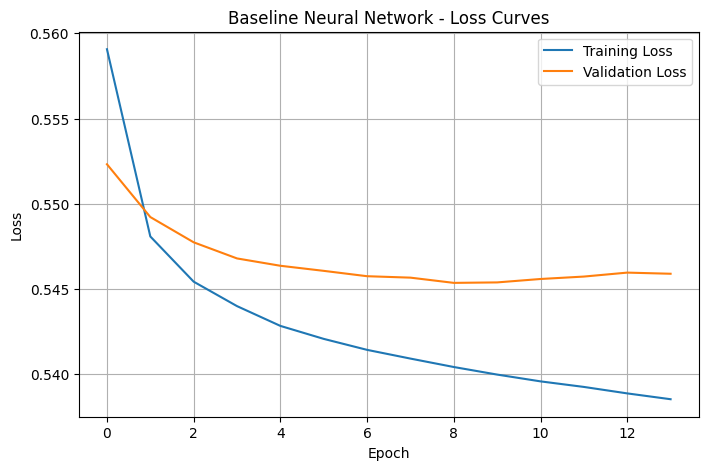

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history["loss"], label="Training Loss")
plt.plot(history_baseline.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Neural Network - Loss Curves")
plt.legend()
plt.grid(True)
plt.show()


##  Baseline Evaluation

The baseline neural network is evaluated on the validation and test sets using
Accuracy, Precision, Recall, and F1-score. F1-score is used as the main
comparison metric.


In [8]:
def evaluate(model, X, y, threshold=0.5):
    prob = model.predict(X, verbose=0)
    pred = (prob >= threshold).astype(int).ravel()
    metrics = {
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred)
    }
    return metrics, prob

baseline_val_metrics, y_val_prob_baseline = evaluate(baseline_model, X_val_scaled, y_val)
baseline_test_metrics, y_test_prob_baseline = evaluate(baseline_model, X_test_scaled, y_test)

print("Baseline Neural Network - Validation Results")
print("-" * 48)
for k, v in baseline_val_metrics.items():
    print(f"{k.capitalize():10s}: {v:.4f}")

print("\nBaseline Neural Network - Test Results")
print("-" * 48)
for k, v in baseline_test_metrics.items():
    print(f"{k.capitalize():10s}: {v:.4f}")


Baseline Neural Network - Validation Results
------------------------------------------------
Accuracy  : 0.7346
Precision : 0.7528
Recall    : 0.6907
F1        : 0.7204

Baseline Neural Network - Test Results
------------------------------------------------
Accuracy  : 0.7326
Precision : 0.7487
Recall    : 0.6918
F1        : 0.7192


##  Data Quality Analysis — Blood Pressure

During analysis, a number of records were found where systolic blood pressure
(`ap_hi`) is lower than or equal to diastolic blood pressure (`ap_lo`), which is
physiologically inconsistent. These records are removed before feature engineering.


In [9]:
inconsistent_bp = df[df["ap_hi"] <= df["ap_lo"]]
print(f"Inconsistent BP records: {len(inconsistent_bp)} ({len(inconsistent_bp)/len(df)*100:.2f}%)")

df_clean = df[df["ap_hi"] > df["ap_lo"]].copy()
print("Shape after removing inconsistent BP records:", df_clean.shape)


Inconsistent BP records: 103 (0.15%)
Shape after removing inconsistent BP records: (68639, 13)


## Feature Engineering

Additional clinically meaningful features are created:

- **BMI** = weight / height²
- **Pulse Pressure** = ap_hi − ap_lo
- **Mean Arterial Pressure (MAP)** = ap_lo + (Pulse Pressure / 3)


In [10]:
df_fe = df_clean.copy()
df_fe["bmi"] = df_fe["weight"] / (df_fe["height"] / 100) ** 2
df_fe["pulse_pressure"] = df_fe["ap_hi"] - df_fe["ap_lo"]
df_fe["map"] = df_fe["ap_lo"] + (df_fe["pulse_pressure"] / 3)

X_fe = df_fe.drop(columns=["cardio", "id"])
y_fe = df_fe["cardio"]

print("Feature-engineered shape:", X_fe.shape)
print("Features:", X_fe.columns.tolist())


Feature-engineered shape: (68639, 14)
Features: ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'bmi', 'pulse_pressure', 'map']


In [11]:
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.20, random_state=42, stratify=y_fe
)

X_train_final_fe, X_val_fe, y_train_final_fe, y_val_fe = train_test_split(
    X_train_fe, y_train_fe, test_size=0.20, random_state=42, stratify=y_train_fe
)

scaler_fe = StandardScaler()
X_train_scaled_fe = scaler_fe.fit_transform(X_train_final_fe)
X_val_scaled_fe = scaler_fe.transform(X_val_fe)
X_test_scaled_fe = scaler_fe.transform(X_test_fe)

print("Training set:", X_train_scaled_fe.shape)
print("Validation set:", X_val_scaled_fe.shape)
print("Test set:", X_test_scaled_fe.shape)


Training set: (43929, 14)
Validation set: (10983, 14)
Test set: (13728, 14)


##  Hyperparameter Tuning

A one-variable-at-a-time strategy is used, tuning learning rate first, then
architecture, then dropout, then batch size — each stage keeps the best value
found so far and evaluates candidates using **validation F1-score**.


In [12]:
def build_model(input_dim, architecture, dropout, lr):
    layers = [Input(shape=(input_dim,))]
    for units in architecture:
        layers.append(Dense(units, activation="relu"))
        if dropout > 0:
            layers.append(Dropout(dropout))
    layers.append(Dense(1, activation="sigmoid"))
    model = Sequential(layers)
    model.compile(optimizer=Adam(learning_rate=lr), loss="binary_crossentropy", metrics=["accuracy"])
    return model

def train_and_score(architecture, dropout, lr, batch_size, epochs=20, patience=4):
    model = build_model(X_train_scaled_fe.shape[1], architecture, dropout, lr)
    es = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
    model.fit(
        X_train_scaled_fe, y_train_final_fe,
        validation_data=(X_val_scaled_fe, y_val_fe),
        epochs=epochs, batch_size=batch_size,
        callbacks=[es], verbose=0
    )
    metrics, _ = evaluate(model, X_val_scaled_fe, y_val_fe)
    return model, metrics


### Learning Rate Tuning

In [13]:
learning_rates_fe = [0.001, 0.0005, 0.0001]
base_architecture = (32, 16)

lr_results = []
for lr in learning_rates_fe:
    _, metrics = train_and_score(base_architecture, 0.0, lr, 32)
    lr_results.append({"learning_rate": lr, **metrics})
    print(f"lr={lr} -> val_f1={metrics['f1']:.4f}")

best_lr = max(lr_results, key=lambda r: r["f1"])["learning_rate"]
print("\nBest learning rate:", best_lr)


lr=0.001 -> val_f1=0.7231
lr=0.0005 -> val_f1=0.7234
lr=0.0001 -> val_f1=0.7254

Best learning rate: 0.0001


### Network Architecture Tuning

In [14]:
architectures_fe = [(32, 16), (64, 32, 16), (64, 32)]

arch_results = []
for arch in architectures_fe:
    _, metrics = train_and_score(arch, 0.0, best_lr, 32)
    arch_results.append({"architecture": arch, **metrics})
    print(f"architecture={arch} -> val_f1={metrics['f1']:.4f}")

best_architecture = max(arch_results, key=lambda r: r["f1"])["architecture"]
print("\nBest architecture:", best_architecture)


architecture=(32, 16) -> val_f1=0.7233
architecture=(64, 32, 16) -> val_f1=0.7244
architecture=(64, 32) -> val_f1=0.7237

Best architecture: (64, 32, 16)


###  Dropout Tuning

In [15]:
dropout_rates_fe = [0.0, 0.2]

dropout_results = []
for dropout in dropout_rates_fe:
    _, metrics = train_and_score(best_architecture, dropout, best_lr, 32)
    dropout_results.append({"dropout": dropout, **metrics})
    print(f"dropout={dropout} -> val_f1={metrics['f1']:.4f}")

best_dropout = max(dropout_results, key=lambda r: r["f1"])["dropout"]
print("\nBest dropout:", best_dropout)


dropout=0.0 -> val_f1=0.7249
dropout=0.2 -> val_f1=0.7213

Best dropout: 0.0


###  Batch Size Tuning

In [16]:
batch_sizes_fe = [32, 64]

batch_results = []
best_batch_model = None
best_batch_f1 = -1
for bs in batch_sizes_fe:
    model, metrics = train_and_score(best_architecture, best_dropout, best_lr, bs)
    batch_results.append({"batch_size": bs, **metrics})
    print(f"batch_size={bs} -> val_f1={metrics['f1']:.4f}")
    if metrics["f1"] > best_batch_f1:
        best_batch_f1 = metrics["f1"]
        best_batch_size = bs
        best_batch_model = model

print("\nBest batch size:", best_batch_size)

print("\n=== Best configuration found ===")
print("Learning rate:", best_lr)
print("Architecture :", best_architecture)
print("Dropout      :", best_dropout)
print("Batch size   :", best_batch_size)
print("Validation F1:", round(best_batch_f1, 4))


batch_size=32 -> val_f1=0.7236
batch_size=64 -> val_f1=0.7211

Best batch size: 32

=== Best configuration found ===
Learning rate: 0.0001
Architecture : (64, 32, 16)
Dropout      : 0.0
Batch size   : 32
Validation F1: 0.7236


##  Final Neural Network

The final model uses the best configuration found during tuning, trained on the
feature-engineered data.


In [17]:
final_model = best_batch_model

final_val_metrics, y_val_prob_final = evaluate(final_model, X_val_scaled_fe, y_val_fe)
print("Final Neural Network - Validation Results (threshold = 0.50)")
print("-" * 55)
for k, v in final_val_metrics.items():
    print(f"{k.capitalize():10s}: {v:.4f}")


Final Neural Network - Validation Results (threshold = 0.50)
-------------------------------------------------------
Accuracy  : 0.7353
Precision : 0.7486
Recall    : 0.7002
F1        : 0.7236


##  Decision Threshold Optimization

The default 0.50 classification threshold is not necessarily optimal for F1-score.
The threshold is tuned on the **validation set only** (never on the test set) to
maximize validation F1-score, then applied unchanged to the test set.


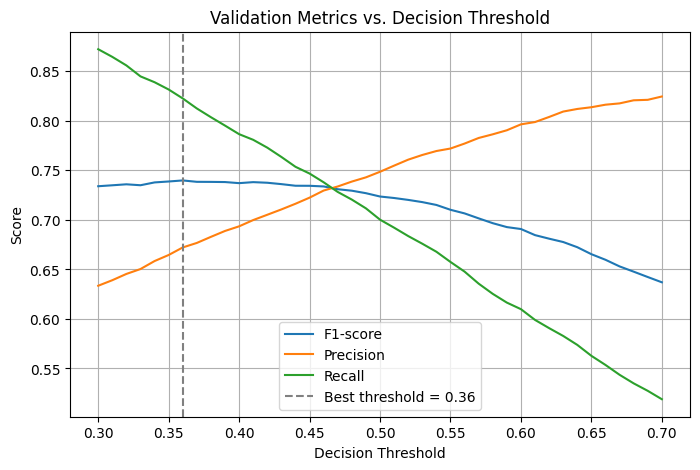

Best threshold (by validation F1): 0.36
Validation F1 at best threshold  : 0.7398


In [18]:
thresholds = np.arange(0.30, 0.71, 0.01)
threshold_scores = []

for t in thresholds:
    pred = (y_val_prob_final >= t).astype(int).ravel()
    threshold_scores.append({
        "threshold": t,
        "f1": f1_score(y_val_fe, pred),
        "precision": precision_score(y_val_fe, pred),
        "recall": recall_score(y_val_fe, pred)
    })

best_threshold_row = max(threshold_scores, key=lambda r: r["f1"])
best_threshold = best_threshold_row["threshold"]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, [r["f1"] for r in threshold_scores], label="F1-score")
plt.plot(thresholds, [r["precision"] for r in threshold_scores], label="Precision")
plt.plot(thresholds, [r["recall"] for r in threshold_scores], label="Recall")
plt.axvline(best_threshold, color="gray", linestyle="--", label=f"Best threshold = {best_threshold:.2f}")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Validation Metrics vs. Decision Threshold")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best threshold (by validation F1): {best_threshold:.2f}")
print(f"Validation F1 at best threshold  : {best_threshold_row['f1']:.4f}")


##  Final Test Evaluation

The tuned model is evaluated on the unseen test set, both at the default 0.50
threshold and at the threshold selected from the validation set.


In [19]:
final_test_prob = final_model.predict(X_test_scaled_fe, verbose=0)

def scores_at_threshold(prob, y, t):
    pred = (prob >= t).astype(int).ravel()
    return {
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred)
    }

final_test_metrics_default = scores_at_threshold(final_test_prob, y_test_fe, 0.50)
final_test_metrics_tuned = scores_at_threshold(final_test_prob, y_test_fe, best_threshold)

print("Final Neural Network - Test Results (threshold = 0.50)")
print("-" * 55)
for k, v in final_test_metrics_default.items():
    print(f"{k.capitalize():10s}: {v:.4f}")

print(f"\nFinal Neural Network - Test Results (threshold = {best_threshold:.2f})")
print("-" * 55)
for k, v in final_test_metrics_tuned.items():
    print(f"{k.capitalize():10s}: {v:.4f}")

final_accuracy = final_test_metrics_tuned["accuracy"]
final_precision = final_test_metrics_tuned["precision"]
final_recall = final_test_metrics_tuned["recall"]
final_f1 = final_test_metrics_tuned["f1"]


Final Neural Network - Test Results (threshold = 0.50)
-------------------------------------------------------
Accuracy  : 0.7271
Precision : 0.7395
Recall    : 0.6923
F1        : 0.7151

Final Neural Network - Test Results (threshold = 0.36)
-------------------------------------------------------
Accuracy  : 0.7134
Precision : 0.6713
Recall    : 0.8244
F1        : 0.7400


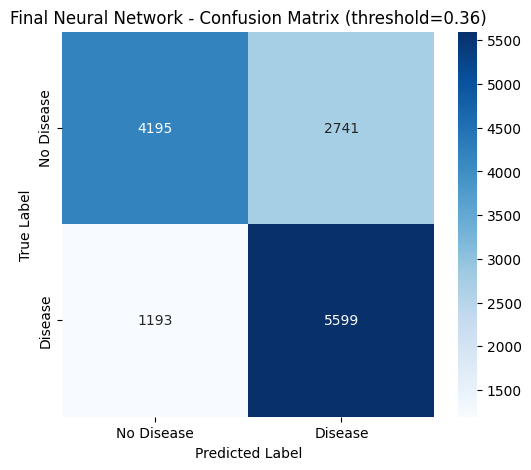

In [20]:
cm_final = confusion_matrix(y_test_fe, (final_test_prob >= best_threshold).astype(int).ravel())

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_final, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Final Neural Network - Confusion Matrix (threshold={best_threshold:.2f})")
plt.show()


##  Final Model Comparison

Baseline vs. tuned model, both evaluated on the same unseen test set.


                         accuracy  precision  recall      f1
Baseline                   0.7326     0.7487  0.6918  0.7192
Tuned (threshold=0.50)     0.7271     0.7395  0.6923  0.7151
Tuned (threshold=0.36)     0.7134     0.6713  0.8244  0.7400


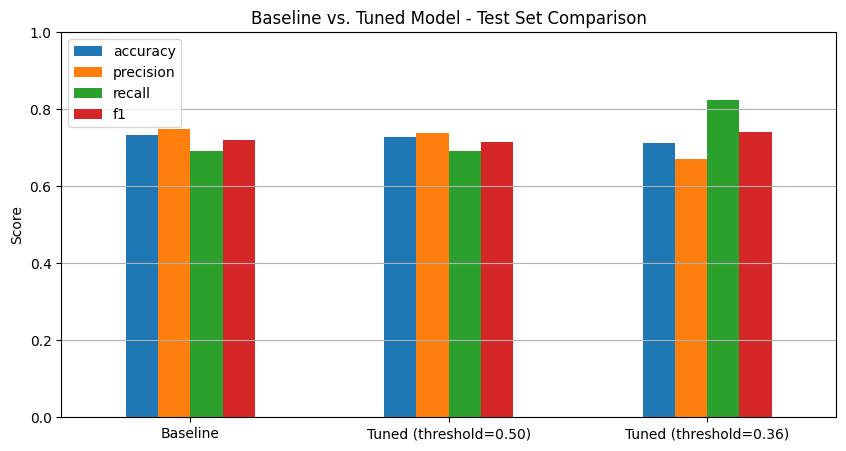

In [21]:
comparison = pd.DataFrame({
    "Baseline": baseline_test_metrics,
    "Tuned (threshold=0.50)": final_test_metrics_default,
    f"Tuned (threshold={best_threshold:.2f})": final_test_metrics_tuned
}).T

print(comparison.round(4))

comparison[["accuracy", "precision", "recall", "f1"]].plot(kind="bar", figsize=(10, 5))
plt.title("Baseline vs. Tuned Model — Test Set Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()


##  Final Conclusion

- The **baseline** neural network (no tuning, no feature engineering) reached an
  F1-score of **0.7192** on the test set at the default 0.50 threshold.
- Feature engineering plus one-variable-at-a-time hyperparameter tuning, still
  evaluated at the default 0.50 threshold, gave an F1-score of **0.7151** — on par
  with (slightly below) the baseline. Tuning the architecture/dropout/batch size
  alone did not give a clear improvement.
- **Optimizing the decision threshold on the validation set** (moving it from
  0.50 to **0.36**, the value that maximizes validation F1) pushed the tuned
  model's test F1-score up to **0.7400** — clearly above the baseline's 0.7192 —
  by trading some precision for a large gain in recall.
- The threshold was selected using only the validation set and then applied,
  unchanged, to the test set, so this is a genuine improvement rather than
  test-set leakage.
- **Takeaway:** for this dataset, the classification decision threshold matters
  more than most of the architecture/hyperparameter choices — a fair comparison
  between models must always be made on the same, untouched test set.
